In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import folium
from folium.plugins import HeatMap
import glob
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

In [2]:
Synthetic = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/synthetic.csv')
Advan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv')

In [3]:
synthetic_agg = (Synthetic.groupby(['lid', 'latitude', 'longitude', 'admin2'])
                 .size()
                 .reset_index(name='visit_count_synthetic'))

advan_agg = (Advan.groupby(['placekey', 'latitude', 'longitude', 'county'])
             .size()
             .reset_index(name='visit_count_advan'))
g_points = synthetic_agg[['latitude', 'longitude', 'visit_count_synthetic']].values.T
r_points = advan_agg[['latitude', 'longitude', 'visit_count_advan']].values.T

k = 10

In [4]:
synthetic_agg.head()

,lid,latitude,longitude,admin2,visit_count_synthetic
0,11505,34.821761,-92.199584,131,2
1,11601,34.714251,-92.222021,131,1
2,469588,37.934128,-75.377465,1,93
3,469588,37.934128,-75.377465,131,8
4,469590,37.932831,-75.360355,1,70


In [75]:
advan_agg.head()

,placekey,latitude,longitude,county,visit_count_advan
0,222-222@63c-9rz-hqz,38.436298,-78.911478,660,1
1,222-222@63c-9rz-ht9,38.435119,-78.910969,165,1
2,222-222@63f-cbx-pqf,37.368502,-78.830032,11,2
3,222-222@63f-dmv-q75,37.372925,-79.195651,680,1
4,222-222@63f-dmz-9s5,37.391426,-79.157344,680,1


In [60]:
county_id = 59

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 59 | Synthetic points: 12001 | Advan points: 694
PCE: 6.3880
RCE: 4.8748
RE:  3.6188


In [61]:
county_id = 153

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 153 | Synthetic points: 11091 | Advan points: 269
PCE: 7.2044
RCE: 6.0360
RE:  3.7644


In [62]:
county_id = 107

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 107 | Synthetic points: 8933 | Advan points: 298
PCE: 6.1947
RCE: 4.7036
RE:  2.6927


In [63]:
county_id = 13

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 13 | Synthetic points: 6474 | Advan points: 478
PCE: 6.5112
RCE: 4.7132
RE:  3.0059


In [64]:
county_id = 810

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 810 | Synthetic points: 6160 | Advan points: 205
PCE: 3.9900
RCE: 2.7506
RE:  1.3351


In [65]:
county_id = 41

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 41 | Synthetic points: 6147 | Advan points: 52
PCE: 2.8818
RCE: 1.4551
RE:  0.3665


In [66]:
county_id = 87

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 87 | Synthetic points: 5964 | Advan points: 121
PCE: 5.2231
RCE: 3.7203
RE:  2.4432


In [67]:
county_id = 179

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 179 | Synthetic points: 5921 | Advan points: 14
PCE: 1.1738
RCE: -0.9951
RE:  -3.2518


In [69]:
county_id = 510

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 510 | Synthetic points: 5709 | Advan points: 292
PCE: 6.2432
RCE: 4.3032
RE:  2.8119


In [70]:
county_id = 550

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 550 | Synthetic points: 5694 | Advan points: 83
PCE: 3.6828
RCE: 2.0493
RE:  0.9419


In [71]:
county_id = 760

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 760 | Synthetic points: 5279 | Advan points: 425
PCE: 8.4628
RCE: 6.9325
RE:  5.9552


In [72]:
county_id = 710

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 710 | Synthetic points: 5138 | Advan points: 74
PCE: 3.7630
RCE: 2.1220
RE:  0.8304


In [73]:
county_id = 3

g_county = synthetic_agg[synthetic_agg['admin2'] == county_id][['latitude', 'longitude', 'visit_count_synthetic']].values
r_county = advan_agg[advan_agg['county'] == county_id][['latitude', 'longitude', 'visit_count_advan']].values

print(f"County: {county_id} | Synthetic points: {len(g_county)} | Advan points: {len(r_county)}")

combined = np.vstack([g_county, r_county])
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_county).T
r_scaled = scaler.transform(r_county).T

knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

# PCE = CE(G,R) - H(R)
dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)   # CE(G,R)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)   # H(R)
CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], 1e-10, None)))
PCE   = CE_GR - H_R

# RCE = CE(R,G) - H(R)
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)   # CE(R,G)
CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], 1e-10, None)))
RCE   = CE_RG - H_R

# RE = H(G) - H(R)
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)   # H(G)
H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], 1e-10, None)))
RE  = H_G - H_R

print(f"PCE: {PCE:.4f}")
print(f"RCE: {RCE:.4f}")
print(f"RE:  {RE:.4f}")

County: 3 | Synthetic points: 2062 | Advan points: 13
PCE: 1.3433
RCE: -0.5570
RE:  -1.5633


In [9]:
k_confirm = 2
g_manual = np.array([
    [37.5, -77.5, 10.0],
    [38.0, -78.0, 5.0],
    [37.8, -77.8, 8.0]
])
r_manual = np.array([
    [37.6, -77.6, 8.0],
    [38.1, -78.1, 6.0],
    [37.9, -77.9, 7.0]
])
knn_r = NearestNeighbors(n_neighbors=k_confirm+1).fit(r_manual)
knn_g = NearestNeighbors(n_neighbors=k_confirm+1).fit(g_manual)
print(f"g_manual:\n{g_manual}")
print(f"\nr_manual:\n{r_manual}")

g_manual:
[[ 37.5 -77.5  10. ]
 [ 38.  -78.    5. ]
 [ 37.8 -77.8   8. ]]

r_manual:
[[ 37.6 -77.6   8. ]
 [ 38.1 -78.1   6. ]
 [ 37.9 -77.9   7. ]]


In [6]:
dist_g_in_r, _ = knn_r.kneighbors(g_manual)

dist_r_in_r, _ = knn_r.kneighbors(r_manual)

CE_GR = np.mean(np.log(np.clip(dist_g_in_r[:, k_confirm-1], 1e-10, None)))
H_R   = np.mean(np.log(np.clip(dist_r_in_r[:, k_confirm-1], 1e-10, None)))
PCE   = CE_GR - H_R

print(f"dist_g_in_r:\n{dist_g_in_r}")
print(f"\ndist_r_in_r:\n{dist_r_in_r}")
print(f"\nCE_GR = {CE_GR:.6f}")
print(f"H_R   = {H_R:.6f}")
print(f"PCE   = {PCE:.6f}")

dist_g_in_r:
[[2.00499377 3.0528675  4.08900966]
 [1.00995049 2.00499377 3.0528675 ]
 [0.28284271 1.00995049 2.04450483]]

dist_r_in_r:
[[0.         1.08627805 2.12132034]
 [0.         1.03923048 2.12132034]
 [0.         1.03923048 1.08627805]]

CE_GR = 0.607208
H_R   = 0.053239
PCE   = 0.553968


In [7]:
dist_r_in_g, _ = knn_g.kneighbors(r_manual)

CE_RG = np.mean(np.log(np.clip(dist_r_in_g[:, k_confirm-1], 1e-10, None)))
RCE   = CE_RG - H_R

print(f"dist_r_in_g:\n{dist_r_in_g}")
print(f"\nCE_RG = {CE_RG:.6f}")
print(f"H_R   = {H_R:.6f}")
print(f"RCE   = {RCE:.6f}")

dist_r_in_g:
[[0.28284271 2.00499377 3.0528675 ]
 [1.00995049 2.04450483 4.08900966]
 [1.00995049 2.00499377 3.0528675 ]]

CE_RG = 0.702146
H_R   = 0.053239
RCE   = 0.648906


In [8]:
dist_g_in_g, _ = knn_g.kneighbors(g_manual)

H_G = np.mean(np.log(np.clip(dist_g_in_g[:, k_confirm-1], 1e-10, None)))
RE  = H_G - H_R

print(f"dist_g_in_g:\n{dist_g_in_g}")
print(f"\nH_G = {H_G:.6f}")
print(f"H_R = {H_R:.6f}")
print(f"RE  = {RE:.6f}")

dist_g_in_g:
[[0.         2.04450483 5.04975247]
 [0.         3.01330383 5.04975247]
 [0.         2.04450483 3.01330383]]

H_G = 0.844449
H_R = 0.053239
RE  = 0.791210


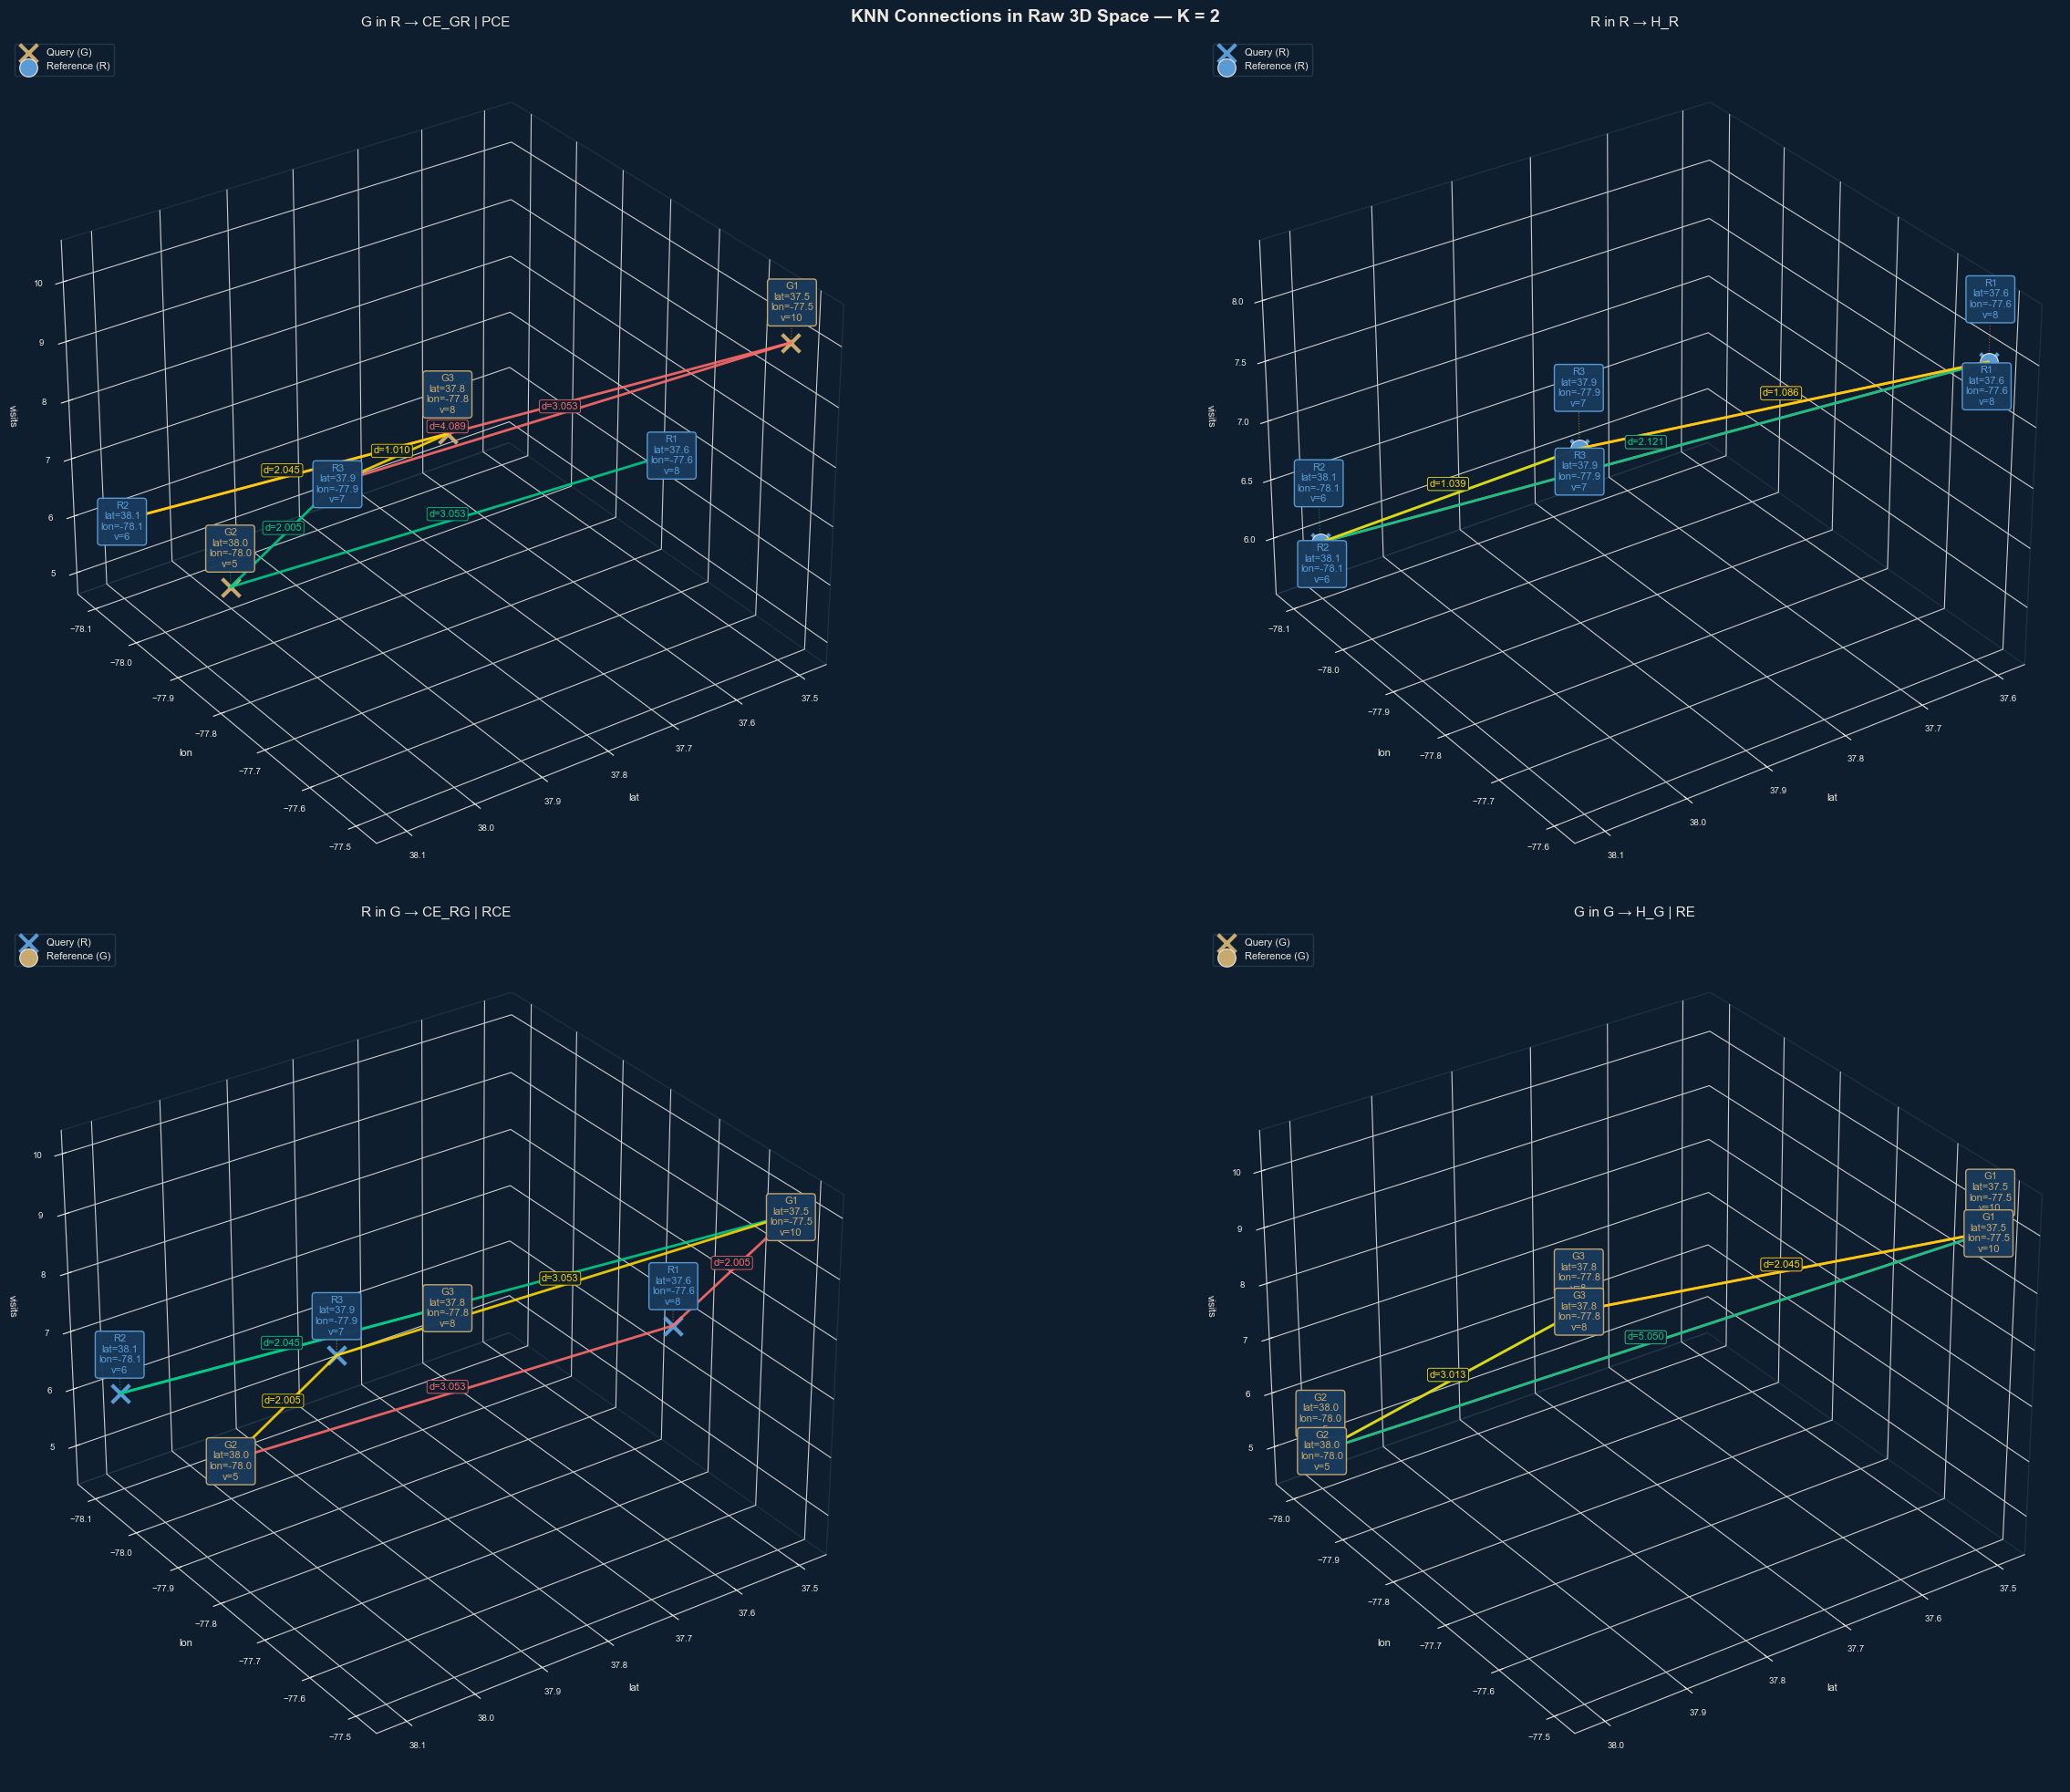

In [10]:
dist_g_in_r, idx_g_in_r = knn_r.kneighbors(g_manual)
dist_r_in_r, idx_r_in_r = knn_r.kneighbors(r_manual)
dist_r_in_g, idx_r_in_g = knn_g.kneighbors(r_manual)
dist_g_in_g, idx_g_in_g = knn_g.kneighbors(g_manual)

fig = plt.figure(figsize=(30, 20))
fig.patch.set_facecolor('#0E1E2E')

configs = [
    (g_manual, r_manual, dist_g_in_r[:, 1:], idx_g_in_r[:, 1:],
     'G in R → CE_GR | PCE', '#C8A96E', '#5B9BD5', 'G', 'R', g_manual, r_manual),
    (r_manual, r_manual, dist_r_in_r[:, 1:], idx_r_in_r[:, 1:],
     'R in R → H_R', '#5B9BD5', '#5B9BD5', 'R', 'R', r_manual, r_manual),
    (r_manual, g_manual, dist_r_in_g[:, 1:], idx_r_in_g[:, 1:],
     'R in G → CE_RG | RCE', '#5B9BD5', '#C8A96E', 'R', 'G', r_manual, g_manual),
    (g_manual, g_manual, dist_g_in_g[:, 1:], idx_g_in_g[:, 1:],
     'G in G → H_G | RE', '#C8A96E', '#C8A96E', 'G', 'G', g_manual, g_manual),
]

line_colors  = ['#FF6B6B', '#00CC88', '#FFD700']
q_z_offsets  = [0.35, 0.35, 0.35]
r_z_offsets  = [-0.35, -0.35, -0.35]

for idx, (query_pos, ref_pos, dist_mat, idx_mat, title,
          qcolor, rcolor, qprefix, rprefix,
          query_raw, ref_raw) in enumerate(configs):

    ax = fig.add_subplot(2, 2, idx+1, projection='3d')
    ax.set_facecolor('#0E1E2E')
    ax.view_init(elev=30, azim=55)

    ax.scatter(query_pos[:, 0], query_pos[:, 1], query_pos[:, 2],
               color=qcolor, s=200, zorder=10, marker='x',
               linewidths=3.0, label=f'Query ({qprefix})', depthshade=False)
    ax.scatter(ref_pos[:, 0], ref_pos[:, 1], ref_pos[:, 2],
               color=rcolor, s=200, zorder=10, marker='o',
               alpha=1.0, label=f'Reference ({rprefix})', depthshade=False,
               edgecolors='#EDE8DF', linewidths=0.8)

    for i in range(len(query_pos)):
        lc = line_colors[i]
        for j in range(dist_mat.shape[1]):
            neighbor_idx = idx_mat[i, j]
            p1 = query_pos[i]
            p2 = ref_pos[neighbor_idx]
            d  = dist_mat[i, j]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                    color=lc, linewidth=2.0, alpha=0.9, zorder=3)
            mid = (p1 + p2) / 2
            ax.text(mid[0], mid[1], mid[2] + 0.08, f'd={d:.3f}',
                    fontsize=8, color=lc, ha='center', zorder=15,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#0E1E2E',
                              edgecolor=lc, linewidth=0.6, alpha=0.95))

    for i, (pt, pt_r) in enumerate(zip(query_pos, query_raw)):
        lc = line_colors[i]
        ax.text(pt[0], pt[1], pt[2] + q_z_offsets[i],
                f'{qprefix}{i+1}\nlat={pt_r[0]:.1f}\nlon={pt_r[1]:.1f}\nv={int(pt_r[2])}',
                fontsize=8, color=qcolor, ha='center', zorder=15,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A3A5C',
                          edgecolor=qcolor, linewidth=1.0, alpha=0.98))
        ax.plot([pt[0], pt[0]], [pt[1], pt[1]],
                [pt[2], pt[2] + q_z_offsets[i] - 0.05],
                color=lc, linewidth=0.8, alpha=0.6, linestyle=':')

    seen = set()
    for i, (pt, pt_r) in enumerate(zip(ref_pos, ref_raw)):
        key = tuple(pt)
        if key in seen:
            continue
        seen.add(key)
        ax.text(pt[0], pt[1], pt[2] + r_z_offsets[i],
                f'{rprefix}{i+1}\nlat={pt_r[0]:.1f}\nlon={pt_r[1]:.1f}\nv={int(pt_r[2])}',
                fontsize=8, color=rcolor, ha='center', zorder=15,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A3A5C',
                          edgecolor=rcolor, linewidth=1.0, alpha=0.98))
        ax.plot([pt[0], pt[0]], [pt[1], pt[1]],
                [pt[2], pt[2] + r_z_offsets[i] + 0.05],
                color=rcolor, linewidth=0.8, alpha=0.6, linestyle=':')

    ax.set_xlabel('lat', fontsize=8, color='#EDE8DF', labelpad=6)
    ax.set_ylabel('lon', fontsize=8, color='#EDE8DF', labelpad=6)
    ax.set_zlabel('visits', fontsize=8, color='#EDE8DF', labelpad=6)
    ax.set_title(title, fontsize=11, color='#EDE8DF', pad=10)
    ax.tick_params(colors='#EDE8DF', labelsize=7)
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('#2A3F55')
    ax.grid(True, color='#2A3F55', linewidth=0.5)
    ax.legend(fontsize=8, facecolor='#0E1E2E', edgecolor='#2A3F55',
              labelcolor='#EDE8DF', loc='upper left')

plt.suptitle('KNN Connections in Raw 3D Space — K = 2',
              fontsize=14, color='#EDE8DF', fontweight='bold')
plt.tight_layout()
plt.show()